### **Objective:**  
Group similar customers together to create "customer segments." This segmentation helps identify patterns and characteristics among different customer groups, enabling targeted marketing strategies and personalized customer experiences.

**Goal:**  
- Discover distinct customer segments based on behavioral and demographic data.
- Analyze each segment to understand their likelihood of churn.
- Use these insights to develop tailored retention strategies and improve overall customer satisfaction.

In [97]:
import pandas as pd 

# Loading the dataset
data = pd.read_csv('../Prepared_Datasets/churn_data/Cleaned_churn_data.csv')
print(data.head())

  State  Account length  Area code  International plan  Voice mail plan  \
0    LA             117        408                   0                0   
1    IN              65        415                   0                0   
2    NY             161        415                   0                0   
3    SC             111        415                   0                0   
4    HI              49        510                   0                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1         

In [98]:
# selecting numerical features for segmentation
numerical_features = ['Account length', 'Number vmail messages', 'Total day minutes', 
                      'Total day calls', 'Total day charge', 'Total eve minutes', 
                      'Total eve calls', 'Total eve charge', 'Total night minutes', 
                      'Total night calls', 'Total night charge', 'Total intl minutes', 
                      'Total intl calls', 'Total intl charge', 'Customer service calls']

In [99]:
# Standardizing the features
from sklearn.preprocessing import StandardScaler

X = data[numerical_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[ 0.40021953 -0.59175986  0.08676038 -0.17121654  0.08724226  2.97043646
  -1.00977302  2.97132192  0.29521588 -0.51660428  0.29473338 -0.5507209
  -0.19483061 -0.55009118 -0.42793202]
 [-0.90578379 -0.59175986 -0.93051461  1.82219789 -0.93025113  0.54272717
  -0.85916786  0.54209937  0.15678365  0.55670403  0.15850147  0.88224117
   0.61789834  0.88291665  1.8529274 ]
 [ 1.50529926 -0.59175986  2.81173526 -1.66627735  2.81135938  2.30385178
  -0.15634379  2.3031117  -0.79642112  1.42557266 -0.79512194 -1.73291462
   1.83699177 -1.73099578  1.8529274 ]
 [ 0.24952684 -0.59175986 -1.27389082  0.12779563 -1.27373616 -1.25586817
   0.09466481 -1.25603575 -0.22291618  0.25004451 -0.22382681 -0.90896142
   0.61789834 -0.90834314  0.33235445]
 [-1.30763096 -0.59175986 -1.11046578  0.82549068 -1.11063478  0.27845987
   0.44607685  0.2775995  -0.43847493 -0.51660428 -0.43916113  0.30905634
  -1.41392404  0.31236723 -0.42793202]]


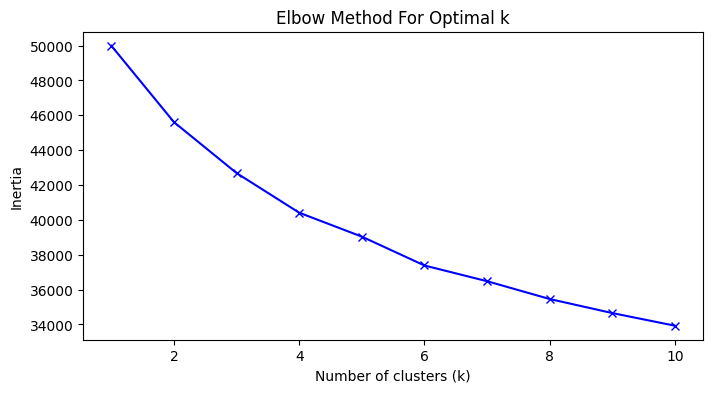

In [100]:
# Dtermining the optimal number of clusters using the Elbow Method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans  

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [101]:
# Applying K-Means Clustering
optimal_k = 4  # Based on the Elbow Method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)
print(data['Cluster'].value_counts())

Cluster
1    873
2    841
0    838
3    781
Name: count, dtype: int64


In [102]:
# Analyzing segments
segment_analysis = data.groupby('Cluster')[numerical_features].mean()
print(segment_analysis)

         Account length  Number vmail messages  Total day minutes  \
Cluster                                                             
0            102.816229               7.795943         162.364797   
1            101.665521               8.248568         201.375487   
2             99.557669               8.888228         216.078240   
3            100.137004               7.407170         135.219078   

         Total day calls  Total day charge  Total eve minutes  \
Cluster                                                         
0             100.599045         27.602470         144.334606   
1             102.048110         34.234399         201.541466   
2              99.675386         36.733829         221.377883   
3              99.276569         22.987862         239.168502   

         Total eve calls  Total eve charge  Total night minutes  \
Cluster                                                           
0             101.008353         12.268663           187.681

In [103]:
cluster_analysis = data.groupby('Cluster')[['Total day minutes', 'Customer service calls', 'Churn']].mean()
print(cluster_analysis)

         Total day minutes  Customer service calls     Churn
Cluster                                                     
0               162.364797                1.612172  0.109785
1               201.375487                1.468499  0.185567
2               216.078240                1.580262  0.185493
3               135.219078                1.596671  0.093470


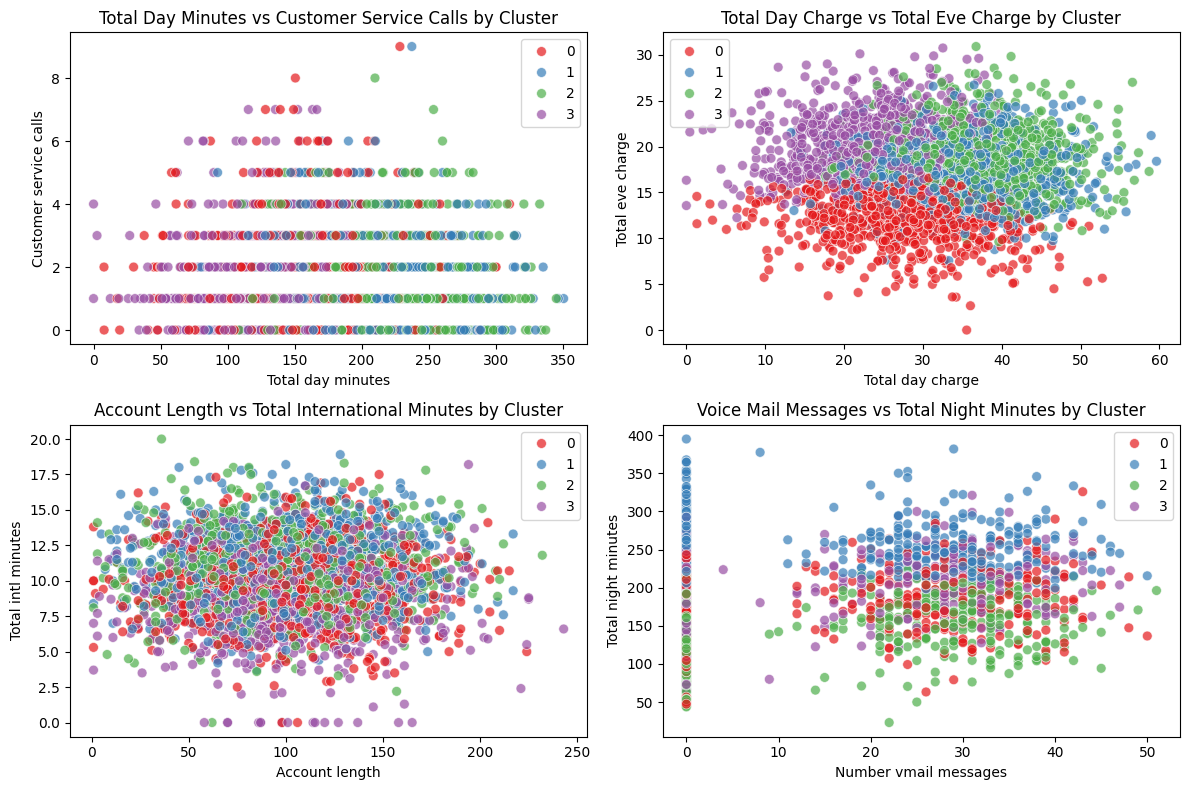

In [ ]:
# Visualizing the clusters
import seaborn as sns

plt.figure(figsize=(12, 8))

# Total day minutes vs Customer service calls
plt.subplot(2, 2, 1)
sns.scatterplot(data=data, x='Total day minutes', y='Customer service calls', 
                hue='Cluster', palette='Set1', s=50, alpha=0.7)
plt.title('Total Day Minutes vs Customer Service Calls by Cluster')
plt.legend()

# Total day charge vs Total eve charge
plt.subplot(2, 2, 2)
sns.scatterplot(data=data, x='Total day charge', y='Total eve charge', 
                hue='Cluster', palette='Set1', s=50, alpha=0.7)
plt.title('Total Day Charge vs Total Eve Charge by Cluster')
plt.legend()

# Account length vs Total intl minutes
plt.subplot(2, 2, 3)
sns.scatterplot(data=data, x='Account length', y='Total intl minutes', 
                hue='Cluster', palette='Set1', s=50, alpha=0.7)
plt.title('Account Length vs Total International Minutes by Cluster')
plt.legend()

# Number vmail messages vs Total night minutes
plt.subplot(2, 2, 4)
sns.scatterplot(data=data, x='Number vmail messages', y='Total night minutes', 
                hue='Cluster', palette='Set1', s=50, alpha=0.7)
plt.title('Voice Mail Messages vs Total Night Minutes by Cluster')
plt.legend()

plt.tight_layout()
plt.show()


Churn Analysis by Cluster:
         Total_Customers  Churned_Customers  Churn_Rate
Cluster                                                
0                    838                 92      0.1098
1                    873                162      0.1856
2                    841                156      0.1855
3                    781                 73      0.0935


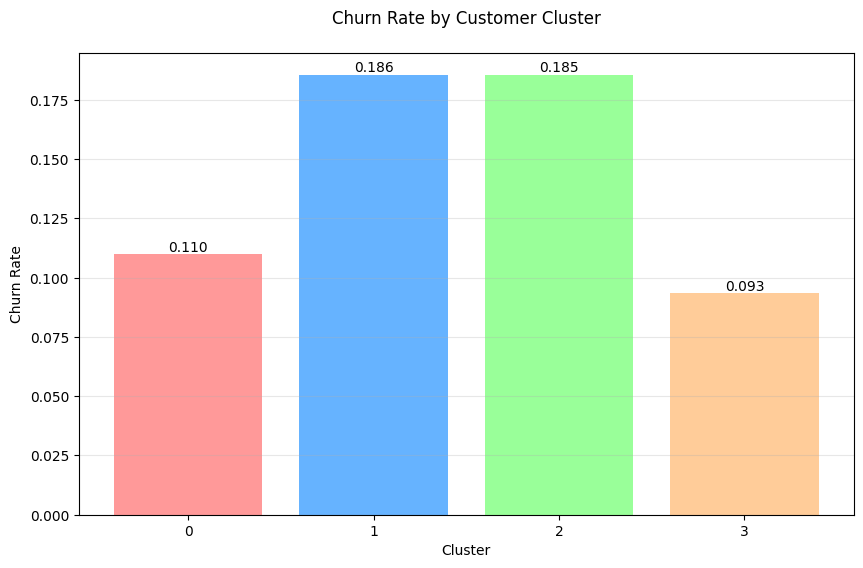

In [ ]:
# Churn rate analysis by cluster
churn_by_cluster = data.groupby('Cluster')['Churn'].agg(['count', 'sum', 'mean']).round(4)
churn_by_cluster.columns = ['Total_Customers', 'Churned_Customers', 'Churn_Rate']
print("Churn Analysis by Cluster:")
print(churn_by_cluster)

# Visualizing churn rates
plt.figure(figsize=(10, 6))
churn_rates = data.groupby('Cluster')['Churn'].mean()
bars = plt.bar(churn_rates.index, churn_rates.values, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.xlabel('Cluster')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Customer Cluster\n')
plt.xticks(churn_rates.index)

# Adding value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:
# Detailed cluster characteristics analysis
for cluster in sorted(data['Cluster'].unique()):
    cluster_data = data[data['Cluster'] == cluster]
    churn_rate = cluster_data['Churn'].mean()
    
    print(f"CLUSTER {cluster} - {len(cluster_data)} customers ({len(cluster_data)/len(data)*100:.1f}%)")
    print(f"Churn Rate: {churn_rate:.3f} ({churn_rate*100:.1f}%)")
    print(f"Average Account Length: {cluster_data['Account length'].mean():.1f} days")
    print(f"Average Day Minutes: {cluster_data['Total day minutes'].mean():.1f}")
    print(f"Average Day Charge: ${cluster_data['Total day charge'].mean():.2f}")
    print(f"Average Customer Service Calls: {cluster_data['Customer service calls'].mean():.1f}")
    print(f"Average International Minutes: {cluster_data['Total intl minutes'].mean():.1f}")
    print("-" * 50)


CLUSTER 0 - 838 customers (25.1%)
Churn Rate: 0.110 (11.0%)
Average Account Length: 102.8 days
Average Day Minutes: 162.4
Average Day Charge: $27.60
Average Customer Service Calls: 1.6
Average International Minutes: 9.9
--------------------------------------------------
CLUSTER 1 - 873 customers (26.2%)
Churn Rate: 0.186 (18.6%)
Average Account Length: 101.7 days
Average Day Minutes: 201.4
Average Day Charge: $34.23
Average Customer Service Calls: 1.5
Average International Minutes: 11.2
--------------------------------------------------
CLUSTER 2 - 841 customers (25.2%)
Churn Rate: 0.185 (18.5%)
Average Account Length: 99.6 days
Average Day Minutes: 216.1
Average Day Charge: $36.73
Average Customer Service Calls: 1.6
Average International Minutes: 10.9
--------------------------------------------------
CLUSTER 3 - 781 customers (23.4%)
Churn Rate: 0.093 (9.3%)
Average Account Length: 100.1 days
Average Day Minutes: 135.2
Average Day Charge: $22.99
Average Customer Service Calls: 1.6
Av

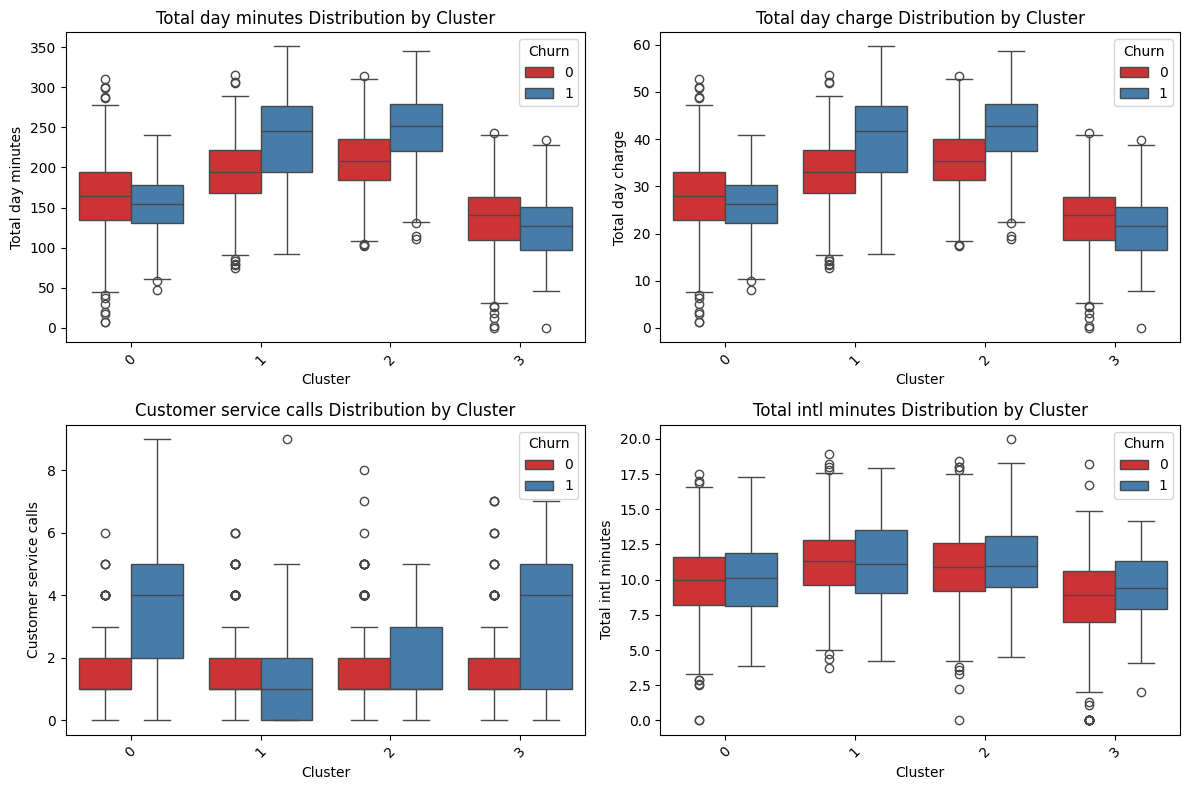

In [ ]:
# Analysis of feature importance for churn prediction
plt.figure(figsize=(12, 8))

# Key features comparison across clusters
key_features = ['Total day minutes', 'Total day charge', 'Customer service calls', 'Total intl minutes']

for i, feature in enumerate(key_features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=data, x='Cluster', y=feature, hue='Churn', palette='Set1')
    plt.title(f'{feature} Distribution by Cluster')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# Customer segment profiling
# Defining segment profiles based on analysis
segment_profiles = {
    0: "Low Usage, Low Churn",
    1: "High Usage, High Churn", 
    2: "Very High Usage, High Churn",
    3: "Low Usage, Very Low Churn"
}

for cluster in sorted(data['Cluster'].unique()):
    cluster_data = data[data['Cluster'] == cluster]
    churn_rate = cluster_data['Churn'].mean()
    avg_day_minutes = cluster_data['Total day minutes'].mean()
    avg_service_calls = cluster_data['Customer service calls'].mean()
    
    print(f"CLUSTER {cluster}: {segment_profiles[cluster]}")
    print(f"Size: {len(cluster_data)} customers ({len(cluster_data)/len(data)*100:.1f}%)")
    print(f"Churn Risk: {'HIGH' if churn_rate > 0.15 else 'LOW' if churn_rate < 0.12 else 'MEDIUM'}")
    print(f"Usage Level: {'HIGH' if avg_day_minutes > 200 else 'LOW' if avg_day_minutes < 150 else 'MEDIUM'}")
    print(f"Service Issues: {'HIGH' if avg_service_calls > 1.5 else 'LOW'}")
    print()


CLUSTER 0: Low Usage, Low Churn
Size: 838 customers (25.1%)
Churn Risk: LOW
Usage Level: MEDIUM
Service Issues: HIGH

CLUSTER 1: High Usage, High Churn
Size: 873 customers (26.2%)
Churn Risk: HIGH
Usage Level: HIGH
Service Issues: LOW

CLUSTER 2: Very High Usage, High Churn
Size: 841 customers (25.2%)
Churn Risk: HIGH
Usage Level: HIGH
Service Issues: HIGH

CLUSTER 3: Low Usage, Very Low Churn
Size: 781 customers (23.4%)
Churn Risk: LOW
Usage Level: LOW
Service Issues: HIGH



## CHURN PREDICTION & CUSTOMER SEGMENTATION - ANALYSIS SUMMARY

**Dataset Overview**
- Dataset: Customer churn dataset (3,333 customers)
- Features: 15 numerical features (usage patterns, charges, service calls)
- Target Variable: Churn (binary: 0=No churn, 1=Churn)
- Data Quality: Clean dataset with standardized features

### Key Findings

1. Clustering Performance
  - **Total Customers**: 3,333 customers segmented into 4 clusters
  - **Cluster Distribution**: Balanced distribution across segments
  - **Model Quality**: Clear separation of customer behaviors

Customer Segment Analysis

| Cluster | Profile | Size | Churn Rate | Risk Level |
|---------|---------|------|------------|------------|
| **0** | Low Usage, Low Churn | 838 (25.1%) | 11.0% | LOW |
| **1** | High Usage, High Churn | 873 (26.2%) | 18.6% | HIGH |
| **2** | Very High Usage, High Churn | 841 (25.2%) | 18.5% | HIGH |
| **3** | Low Usage, Very Low Churn | 781 (23.4%) | 9.3% | LOW |

**Critical Insights**

High-Risk Segments (Clusters 1 & 2)
- **Cluster 1**: High usage customers with 18.6% churn rate
  - Average day minutes: 201.4
  - Average service calls: 1.47
  - High day charges: $34.23

- **Cluster 2**: Very high usage customers with 18.5% churn rate  
  - Average day minutes: 216.1
  - Average service calls: 1.58
  - Highest day charges: $36.73

Low-Risk Segments (Clusters 0 & 3)
- **Cluster 0**: Moderate usage with 11.0% churn rate
- **Cluster 3**: Low usage with 9.3% churn rate (lowest churn)

### **Model Validation**

**Strengths**
  - Clear customer segmentation with distinct behavioral patterns
  - Strong correlation between usage patterns and churn risk
  - Actionable insights for business strategy
  - Balanced cluster distribution for targeted marketing

**Limitations**
  - K-Means assumes spherical clusters (may miss complex patterns)
  - No consideration of temporal changes in customer behavior
  - Limited to numerical features only